# Part 02 — Vision Brain (ResNet + Autoencoder)

Satellite notebook split from `capstone_with_results.ipynb` to keep the master lighter to open.
Outputs/source sync automatically via `scripts/sync_notebook_parts.py` (run the final sync cell).

⚠️ **Run the PART BOOTSTRAP cell first** (defines `TORCH_OK`, paths, imports). Then run vision cells in order: 6.1 → 6.2 → 6.2b → 6.2d → 6.2c → sync.


In [1]:
# ── PART BOOTSTRAP: Part 02 — Vision Brain (ResNet + Autoencoder) ──
# Lightweight satellite notebook — syncs back into notebooks/capstone_with_results.ipynb
import sys
from pathlib import Path

def _find_root() -> Path:
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / "src" / "vision_brain.py").is_file() and (base / "explanations" / "build_all.py").is_file():
            return base
        if (base / "src" / "vision_brain.py").is_file():
            return base
    return Path.cwd().parent if Path.cwd().name in {"notebooks", "parts"} else Path.cwd()

REPO_ROOT = _find_root()
SRC = REPO_ROOT / "src"
DATA = REPO_ROOT / "Data"
if not DATA.is_dir():
    DATA = REPO_ROOT / "data"
sys.path.insert(0, str(SRC))
sys.path.insert(0, str(REPO_ROOT / "scripts")) if (REPO_ROOT / "scripts").is_dir() else None

try:
    import torch
    TORCH_OK = True
except Exception:
    TORCH_OK = False

# Optional shared helpers used by several sections
try:
    from cm_helpers import plot_confusion_matrices_pair  # noqa: F401
except Exception:
    plot_confusion_matrices_pair = None

import numpy as np  # noqa: F401
import pandas as pd  # noqa: F401
import matplotlib.pyplot as plt  # noqa: F401

print(f"Part notebook ready | root={REPO_ROOT} | TORCH_OK={TORCH_OK} | DATA={DATA}")
print("When finished: run the last cell to sync outputs → capstone_with_results.ipynb")

Part notebook ready | root=/home/afolabimayowa/Documents/INFO53883 - AI & ML Capstone Project | TORCH_OK=True | DATA=/home/afolabimayowa/Documents/INFO53883 - AI & ML Capstone Project/Data
When finished: run the last cell to sync outputs → capstone_with_results.ipynb


## Section 6.1 · Vision Brain — Road Image Sources (Ontario)

> ▶ **Fold arrow:** hover the **left margin** of this markdown cell — click to hide/show cells below until the next section.

This section documents data sources for the CNN road-surface classifier (Pillar 2).

### 6.1 Primary – Local `vision_cache/` (project image cache)
- Curated road-surface frames used for ResNet18 transfer learning in this notebook
- **Labels**: Clear / Wet / Snow / Ice (mapped to project hazard classes)
- Populated from HuggingFace RSCD and/or Ontario 511 sample frames when live labels are limited

### 6.2 Live Feed – Ontario 511 CCTV
- Real-time JPEG frames from Highway 400/401 corridor cameras
- API: http://511on.ca/developers/resources

### 6.3 Supplementary – HuggingFace RSCD-1M
- 1 million road images, 27 condition classes
- `pip install datasets` then `load_dataset("keremberke/road-surface-classification")`

**What this cell does:** Documents Ontario-focused image data sources (local vision_cache/, Ontario 511 cameras, HuggingFace RSCD) for the Vision Brain pillar.

**How the code works:**
- Documents image sources: local vision_cache/, Ontario 511 cameras, HuggingFace RSCD.
- Explains why vision_cache/ is used when live labels are limited.


In [2]:
# ── Vision Brain data source reference ───────────────────────────────────────
print("Vision Brain (Pillar 2) – Data Sources Summary")
print("=" * 55)
print()
print("1. Local vision_cache/ (project training cache)")
print("   Path : Data/vision_cache/")
print("   Use  : ResNet18 fine-tuning on Clear / Wet / Snow / Ice classes")
print()
print("2. Ontario 511 Developer API (live camera frames)")
print("   URL  : http://511on.ca/developers/resources")
print("   Feed : JPEG frames from 400-series highway cameras")
print()
print("3. HuggingFace RSCD-1M (general road conditions)")
print("   Install: pip install datasets")
print("   Load  : from datasets import load_dataset")
print("           ds = load_dataset('keremberke/road-surface-classification')")
print()
print("CNN Input Specification:")
print("  Input  : (224, 224, 3) RGB image, pixels scaled [0, 1]")
print("  Output : Softmax over 4 classes [Clear, Wet, Snow, Ice]")
print("  V score: probability of hazard class (used in Safety Score S)")

Vision Brain (Pillar 2) – Data Sources Summary

1. Local vision_cache/ (project training cache)
   Path : Data/vision_cache/
   Use  : ResNet18 fine-tuning on Clear / Wet / Snow / Ice classes

2. Ontario 511 Developer API (live camera frames)
   URL  : http://511on.ca/developers/resources
   Feed : JPEG frames from 400-series highway cameras

3. HuggingFace RSCD-1M (general road conditions)
   Install: pip install datasets
   Load  : from datasets import load_dataset
           ds = load_dataset('keremberke/road-surface-classification')

CNN Input Specification:
  Input  : (224, 224, 3) RGB image, pixels scaled [0, 1]
  Output : Softmax over 4 classes [Clear, Wet, Snow, Ice]
  V score: probability of hazard class (used in Safety Score S)


**Findings & importance:** Establishes provenance for the vision component — reviewers can trace where road-condition images originate and why transfer learning is used when live camera labels are limited.

**What to check in the output:** Markdown reference only — no numeric output; confirms data provenance for the Vision pillar.


## Section 6.2 · Vision Brain — Sample Images & Fine-Tuning

> ▶ **Fold arrow:** hover the **left margin** of this markdown cell — click to hide/show cells below until the next section.

**Goal:** Show your manager how the Vision Brain *sees* road conditions, then fine-tune a CNN.

| Step | What you will see |
|------|-------------------|
| **6.1** | Sample images: **Clear asphalt**, **Wet/Slush**, **Snow/Ice** |
| **6.2** | Fine-tune **ResNet18** (transfer learning) on road-surface images |
| **6.3** | Validation accuracy + confusion matrix → feeds **V score** in Safety Score S |

**Data source:** HuggingFace `keremberke/road-surface-classification` (proxy for Ontario RWIS cameras).  
Install once if needed: `pip install datasets torchvision`

**What this cell does:** Loads cached road-condition photos (clear, wet, snow/ice) from `vision_cache/` and displays a sample grid.

**How the code works:**
- Loads JPEGs from `Data/vision_cache/` subfolders (clear, wet, snow, ice).
- Displays a grid of sample images per surface class.


Loaded 9 cached photos from /home/afolabimayowa/Documents/INFO53883 - AI & ML Capstone Project/Data/vision_cache.
Conditions shown: Clear Asphalt, Wet / Slush, Snow / Ice
Total sample images: 9


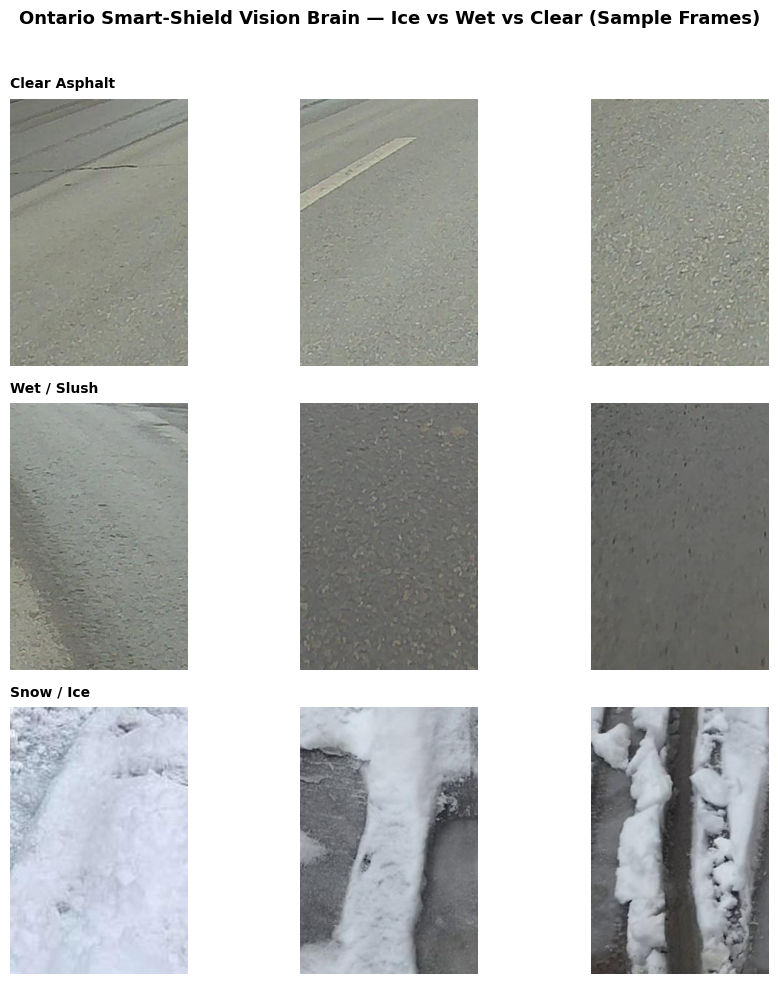

In [3]:
# ── 6.1  Display sample road-condition images ─────────────────────────────────
# Offline-first: reads Data/vision_cache/ or uses demo panels (no HuggingFace at runtime).
# Optional one-time seed: python seed_vision_cache.py

import sys
import importlib
from pathlib import Path

if "vision_brain" in sys.modules:
    del sys.modules["vision_brain"]
import vision_brain
importlib.reload(vision_brain)

from vision_brain import load_sample_images, display_condition_samples, DISPLAY_ORDER, resolve_cache_dir

VISION_CACHE = str(resolve_cache_dir() if "DATA" not in dir() else (DATA / "vision_cache" if (DATA / "vision_cache").is_dir() else DATA.parent / "Data" / "vision_cache"))
SAMPLES_PER_CLASS = 3

sample_images, sample_labels = load_sample_images(
    n_per_class=SAMPLES_PER_CLASS,
    cache_dir=VISION_CACHE,
)

print("Conditions shown:", ", ".join(DISPLAY_ORDER))
print(f"Total sample images: {len(sample_images)}")
display_condition_samples(
    sample_images,
    sample_labels,
    title="Ontario Smart-Shield Vision Brain — Ice vs Wet vs Clear (Sample Frames)",
)


**Findings & importance:** Visual confirmation that the Vision Brain has labelled examples for each surface class. These images feed ResNet18 fine-tuning and the demo's V-score (vision hazard probability).

**What to check in the output:** Image grid showing distinct road-surface examples used for ResNet18 fine-tuning.


### 6.2 · Fine-Tune the Vision Model

We use **transfer learning**: start from ImageNet weights, replace the final layer for 3 road classes, and fine-tune on a subset (~120 images/class for speed).

| Setting | Value | Why |
|---------|-------|-----|
| Backbone | ResNet18 | Fast, good for demo + Colab |
| Input size | 224×224 RGB | Standard CNN input |
| Epochs | 8 | Enough to show learning without long waits |
| Metric | Val accuracy | Simple manager-friendly score |


**What this cell does:** Fine-tunes a ResNet18 classifier on road-surface conditions using cached images (with synthetic augmentation if the cache is small).

**How the code works:**
- Loads ImageNet-pretrained ResNet18, replaces the final layer for 4–6 road classes.
- Trains on cached images with augmentation; saves `vision_resnet18.pt`.


Building training subset (all cached RSCD photos + on-the-fly augmentation)...


Real photos by class: {'Clear Asphalt': 324, 'Wet / Slush': 400, 'Snow / Ice': 362}  (total=1086)
Training on 1086 unique RSCD photos | train views/epoch=1694 | val=239 | oversample×2 | FAST mode
Train views/epoch: 1694  |  Val: 239  |  Classes: ['Clear Asphalt', 'Wet / Slush', 'Snow / Ice']
Fine-tuning on cuda for up to 6 epochs (patience=2)...
ResNet18: backbone frozen (training layer4 + fc only).


  Epoch 1/6  loss=0.4955  val_loss=0.3493  val_acc=84.94%


  Epoch 2/6  loss=0.1884  val_loss=0.3279  val_acc=87.03%


  Epoch 3/6  loss=0.1246  val_loss=0.3400  val_acc=88.28%


  Epoch 4/6  loss=0.1082  val_loss=0.3904  val_acc=87.03%
  Early stop at epoch 4 (val_loss plateau, patience=2).
Restored best checkpoint (val_loss=0.3279).


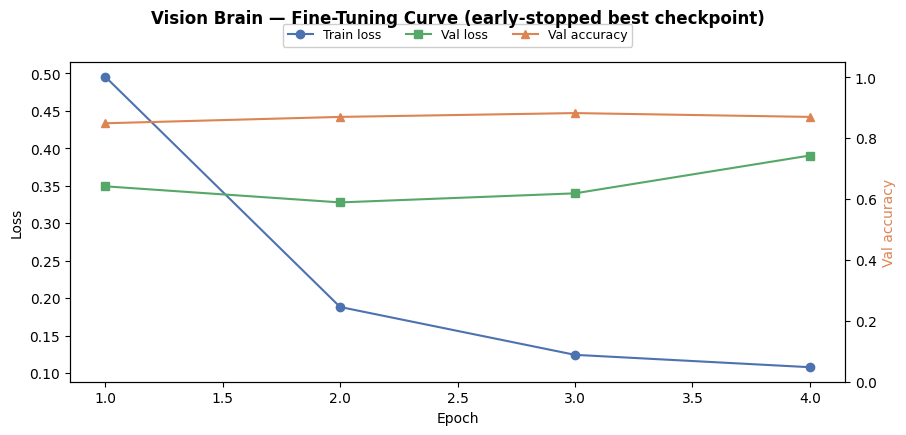


Vision Brain validation accuracy: 87.03%


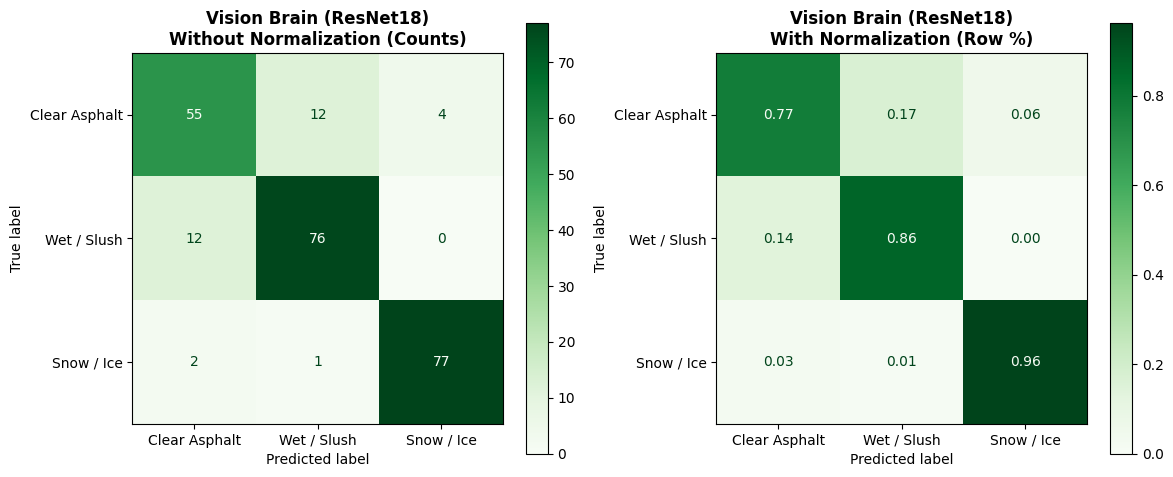

ResNet V_class (hazard P) on one frame: 0.061  true=Clear Asphalt
  → Next: train AE (6.2b), then compare/select backend for equation V (6.2d).


In [4]:
# ── 6.2  Fine-tune ResNet18 on road-surface conditions ────────────────────────

# Ensure runtime if PART BOOTSTRAP was skipped
if "TORCH_OK" not in globals():
    import sys
    from pathlib import Path as _P
    for _base in [_P.cwd(), *_P.cwd().parents]:
        if (_base / "src" / "vision_brain.py").is_file():
            if str(_base / "src") not in sys.path:
                sys.path.insert(0, str(_base / "src"))
            if "DATA" not in globals():
                _d = _base / "Data"
                globals()["DATA"] = _d if _d.is_dir() else _base / "data"
            if "REPO_ROOT" not in globals():
                globals()["REPO_ROOT"] = _base
            break
    try:
        import torch  # noqa: F401
        TORCH_OK = True
    except Exception:
        TORCH_OK = False

vision_model = None
vision_history = None
vision_class_names = None
vision_val_acc = None

if not TORCH_OK:
    print("PyTorch not available (TORCH_OK=False). Install torch, restart kernel, rerun.")
else:
    import sys
    import importlib
    import torch

    if "vision_brain" in sys.modules:
        del sys.modules["vision_brain"]
    import vision_brain
    importlib.reload(vision_brain)

    from vision_brain import (
        build_training_dataset,
        fine_tune_vision_model,
        plot_vision_training,
        evaluate_vision_model,
        DISPLAY_ORDER,
        resolve_cache_dir,
    )
    from sklearn.metrics import ConfusionMatrixDisplay

    VISION_CACHE = str(resolve_cache_dir() if "DATA" not in dir() else (DATA / "vision_cache" if (DATA / "vision_cache").is_dir() else DATA.parent / "Data" / "vision_cache"))
    VISION_FAST = True                 # CPU-friendly defaults (set False for full fine-tune)
    VISION_TRAIN_PER_CLASS = 40 if VISION_FAST else 120
    VISION_EPOCHS = 6 if VISION_FAST else 15
    VISION_LR = 1e-4 if VISION_FAST else 3e-5   # higher LR ok when backbone is mostly frozen
    VISION_PATIENCE = 2 if VISION_FAST else 4

    print("Building training subset (all cached RSCD photos + on-the-fly augmentation)...")
    train_ds, val_ds, vision_class_names = build_training_dataset(
        max_per_class=VISION_TRAIN_PER_CLASS,
        cache_dir=VISION_CACHE,
        target_train_size=VISION_TRAIN_PER_CLASS * len(DISPLAY_ORDER),
        fast=VISION_FAST,
        max_oversample=4 if VISION_FAST else 6,
    )
    print(f"Train views/epoch: {len(train_ds)}  |  Val: {len(val_ds)}  |  Classes: {vision_class_names}")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Fine-tuning on {device} for up to {VISION_EPOCHS} epochs (patience={VISION_PATIENCE})...")
    vision_model, vision_history, vision_class_names = fine_tune_vision_model(
        train_ds, val_ds,
        epochs=VISION_EPOCHS,
        lr=VISION_LR,
        patience=VISION_PATIENCE,
        device=device,
        freeze_backbone=VISION_FAST,
    )
    plot_vision_training(vision_history)

    vision_val_acc, vision_cm, y_true, y_pred = evaluate_vision_model(
        vision_model, val_ds, vision_class_names, device=device,
    )
    print(f"\nVision Brain validation accuracy: {vision_val_acc:.2%}")

    plot_confusion_matrices_pair(
        y_true, y_pred, labels=vision_class_names,
        title_prefix="Vision Brain (ResNet18)",
        cmap="Greens",
    )

    vision_model.eval()
    x0, y0 = val_ds[0]
    with torch.no_grad():
        probs = torch.softmax(vision_model(x0.unsqueeze(0).to(device)), dim=1).cpu().numpy()[0]
# ResNet-only V preview (hybrid comparison/selection runs in 6.2d after AE training)
    from vision_brain import v_class_from_resnet, HAZARD_CLASSES
    v_score = float(v_class_from_resnet(vision_model, x0, vision_class_names, device=device))
    print(f"ResNet V_class (hazard P) on one frame: {v_score:.3f}  true={vision_class_names[int(y0)]}")
    print("  → Next: train AE (6.2b), then compare/select backend for equation V (6.2d).")

### 6.2b · Autoencoder Anomaly Sensor (Hybrid Vision Brain)

**Why add an autoencoder?** Our labelled Ontario road-image cache is small. A supervised ResNet18
classifier handles **known** surface classes well, but may miss **unseen** winter hazards.

| Component | Type | Output | Role |
|-----------|------|--------|------|
| **ResNet18** | Supervised classifier | `V_class` | P(Wet) + P(Snow/Ice) from softmax |
| **Conv Autoencoder** | Unsupervised (Clear Asphalt only) | `V_anomaly` | High reconstruction error → unusual surface |
| **Fusion** | Weighted blend | `V_vision` | `α·V_class + (1−α)·V_anomaly` |

Training uses **early stopping** on validation MSE (best checkpoint restored).
After AE training, Section **6.2d** compares ResNet-only vs hybrid and selects the better backend for equation *V*.

> Default fusion weight when hybrid wins: **α = 0.70**.

**Note:** Flat pink/grey reconstructions mean the AE collapsed to mean asphalt colour. Re-run this cell after the updated `vision_brain.py` (denoising AE, more epochs) — you should see blurry but recognizable road texture, not a solid block.


Building Clear Asphalt dataset for autoencoder...


Autoencoder: 324 clear frames -> 324 samples (train=275, val=49)
Training autoencoder on cuda for up to 20 epochs (patience=4, early stop on val MSE)...


  AE Epoch 1/20  train_mse=0.03057  val_mse=0.02257
  AE Epoch 2/20  train_mse=0.02137  val_mse=0.01327


  AE Epoch 3/20  train_mse=0.01228  val_mse=0.00781
  AE Epoch 4/20  train_mse=0.00929  val_mse=0.00702
  AE Epoch 5/20  train_mse=0.00716  val_mse=0.00570


  AE Epoch 6/20  train_mse=0.00620  val_mse=0.00514
  AE Epoch 7/20  train_mse=0.00574  val_mse=0.00496
  AE Epoch 8/20  train_mse=0.00534  val_mse=0.00434


  AE Epoch 9/20  train_mse=0.00495  val_mse=0.00401
  AE Epoch 10/20  train_mse=0.00459  val_mse=0.00367
  AE Epoch 11/20  train_mse=0.00420  val_mse=0.00332


  AE Epoch 12/20  train_mse=0.00383  val_mse=0.00360
  AE Epoch 13/20  train_mse=0.00360  val_mse=0.00288
  AE Epoch 14/20  train_mse=0.00358  val_mse=0.00261


  AE Epoch 15/20  train_mse=0.00325  val_mse=0.00247
  AE Epoch 16/20  train_mse=0.00280  val_mse=0.00233
  AE Epoch 17/20  train_mse=0.00257  val_mse=0.00202


  AE Epoch 18/20  train_mse=0.00240  val_mse=0.00188
  AE Epoch 19/20  train_mse=0.00225  val_mse=0.00186
  AE Epoch 20/20  train_mse=0.00215  val_mse=0.00181
Restored best AE checkpoint (val_mse=0.00181 @ epoch 20).


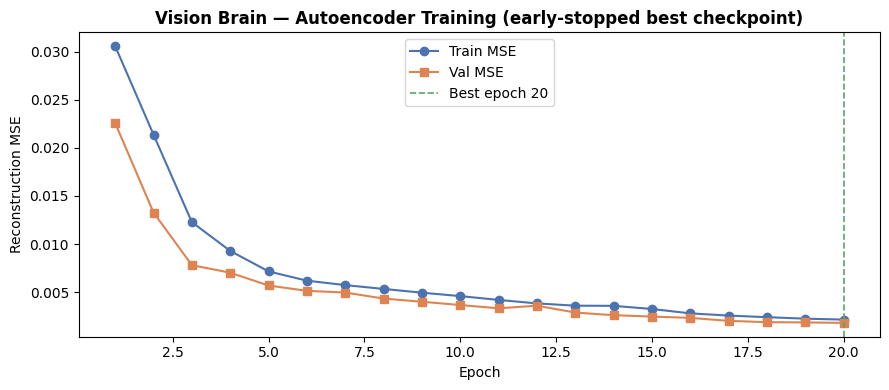

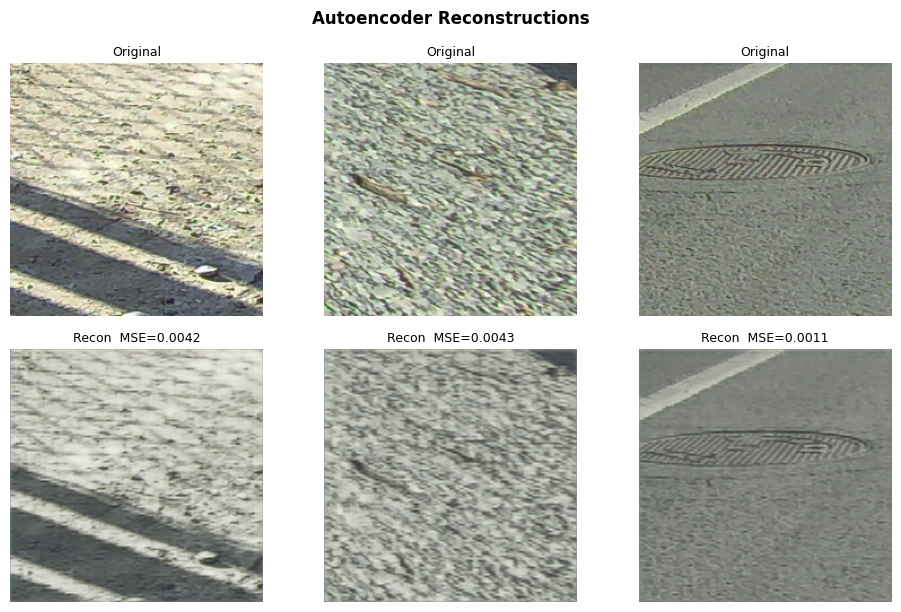

Note: Soft/blurry reconstructions are normal for MSE autoencoders on asphalt texture. You should still see coarse structure (lanes, brightness). Solid pink/grey slabs with no structure mean retraining is needed.
Anomaly threshold (95th pct clear-road MSE): 0.005017

Reconstruction error by class (higher = more anomalous):
  scoring Clear Asphalt (8 frames)...


  Clear Asphalt     mean MSE=0.19993  mean V_vision=0.488
  scoring Wet / Slush (8 frames)...


  Wet / Slush       mean MSE=0.60331  mean V_vision=0.944
  scoring Snow / Ice (8 frames)...


  Snow / Ice        mean MSE=0.31542  mean V_vision=0.995
6.2b complete.


In [5]:
# ── 6.2b  Train autoencoder on Clear Asphalt (early stopping) ─────────────────

# Ensure runtime if PART BOOTSTRAP was skipped
if "TORCH_OK" not in globals():
    import sys
    from pathlib import Path as _P
    for _base in [_P.cwd(), *_P.cwd().parents]:
        if (_base / "src" / "vision_brain.py").is_file():
            if str(_base / "src") not in sys.path:
                sys.path.insert(0, str(_base / "src"))
            if "DATA" not in globals():
                _d = _base / "Data"
                globals()["DATA"] = _d if _d.is_dir() else _base / "data"
            if "REPO_ROOT" not in globals():
                globals()["REPO_ROOT"] = _base
            break
    try:
        import torch  # noqa: F401
        TORCH_OK = True
    except Exception:
        TORCH_OK = False

ae_model = None
ae_history = None
anomaly_threshold = None
VISION_FUSION_ALPHA = 0.70
VISION_AE_PATIENCE = 4 if globals().get('VISION_FAST', True) else 6

# Safe if Section 6.2 was skipped
vision_model = globals().get("vision_model")
val_ds = globals().get("val_ds")
vision_class_names = globals().get("vision_class_names")
device = globals().get("device", "cpu")

if not TORCH_OK:
    print("PyTorch not available — skip autoencoder branch.")
elif vision_model is None:
    print("Run Section 6.2 first (ResNet18 fine-tuning).")
else:
    import importlib
    import sys
    from pathlib import Path
    if "vision_brain" in sys.modules:
        del sys.modules["vision_brain"]
    import vision_brain
    importlib.reload(vision_brain)

    from vision_brain import (
        build_clear_only_dataset,
        train_road_autoencoder,
        plot_autoencoder_training,
        calibrate_anomaly_threshold,
        score_frame_hybrid,
        plot_reconstruction_samples,
        DISPLAY_ORDER,
    )

    print("Building Clear Asphalt dataset for autoencoder...")
    ae_train_ds, ae_val_ds = build_clear_only_dataset(
        max_per_class=VISION_TRAIN_PER_CLASS,
        cache_dir=VISION_CACHE,
    )

    ae_epochs = 20 if globals().get('VISION_FAST', True) else max(25, VISION_EPOCHS)
    print(
        f"Training autoencoder on {device} for up to {ae_epochs} epochs "
        f"(patience={VISION_AE_PATIENCE}, early stop on val MSE)..."
    )
    ae_model, ae_history = train_road_autoencoder(
        ae_train_ds, ae_val_ds,
        epochs=ae_epochs,
        patience=VISION_AE_PATIENCE,
        device=device,
    )
    plot_autoencoder_training(ae_history)
    plot_reconstruction_samples(ae_model, ae_val_ds, n=3, device=device)

    anomaly_threshold = calibrate_anomaly_threshold(ae_model, ae_val_ds, device=device)
    print(f"Anomaly threshold (95th pct clear-road MSE): {anomaly_threshold:.6f}")

    # Fast class summary — use stored labels (avoid re-scanning/transforming the whole val set)
    print("\nReconstruction error by class (higher = more anomalous):")
    if hasattr(val_ds, "labels"):
        y_all = list(val_ds.labels)
    else:
        y_all = [int(val_ds[i][1]) for i in range(len(val_ds))]
    for cls in DISPLAY_ORDER:
        idxs = [i for i, y in enumerate(y_all) if vision_class_names[int(y)] == cls][:8]
        if not idxs:
            print(f"  {cls:<16}  (no val samples)")
            continue
        print(f"  scoring {cls} ({len(idxs)} frames)...", flush=True)
        errs, hybrid_scores = [], []
        for i in idxs:
            x_i, _ = val_ds[i]
            h = score_frame_hybrid(
                vision_model, ae_model, x_i, vision_class_names,
                anomaly_threshold=anomaly_threshold,
                alpha=VISION_FUSION_ALPHA,
                device=device,
            )
            errs.append(h["recon_error"])
            hybrid_scores.append(h["V_vision"])
        print(f"  {cls:<16}  mean MSE={np.mean(errs):.5f}  mean V_vision={np.mean(hybrid_scores):.3f}")
    print("6.2b complete.")

**Findings & importance:** Hybrid Vision Brain combines supervised class probabilities with an unsupervised anomaly signal — valuable when labelled winter-road images are scarce.

**What to check:** Autoencoder MSE decreases; Snow/Ice shows higher reconstruction error than Clear Asphalt; artifacts saved to `models/`.


### 6.2d · ResNet vs ResNet+Autoencoder — Compare & Select for Equation V

We train **ResNet18 first** (Section 6.2), then the **hybrid** ResNet+AE stack (6.2b).
This cell builds a side-by-side metrics table and **automatically selects** the stronger backend
to feed Vision term *V* in:

$$S = (w_T \cdot T + w_V \cdot V + w_E \cdot E_{index}) \times 100$$

| Backend | V definition |
|---------|--------------|
| **ResNet18** | `V = V_class = P(Wet) + P(Snow/Ice)` |
| **ResNet18 + Autoencoder** | `V = α·V_class + (1−α)·V_anomaly` |

**Selection score** rewards Snow/Ice vs Clear separation (+ Wet vs Clear) and a Snow≥Wet≥Clear ranking bonus.
Ties prefer the simpler ResNet-only model.

In [6]:
# ── 6.2d  Compare ResNet vs Hybrid + select backend for Safety Score V ────────

# Ensure runtime if PART BOOTSTRAP was skipped
if "TORCH_OK" not in globals():
    import sys
    from pathlib import Path as _P
    for _base in [_P.cwd(), *_P.cwd().parents]:
        if (_base / "src" / "vision_brain.py").is_file():
            if str(_base / "src") not in sys.path:
                sys.path.insert(0, str(_base / "src"))
            if "DATA" not in globals():
                _d = _base / "Data"
                globals()["DATA"] = _d if _d.is_dir() else _base / "data"
            if "REPO_ROOT" not in globals():
                globals()["REPO_ROOT"] = _base
            break
    try:
        import torch  # noqa: F401
        TORCH_OK = True
    except Exception:
        TORCH_OK = False

vision_comparison_df = None
vision_selection = {
    "selected_backend": "ResNet18",
    "use_hybrid": False,
    "fusion_alpha": 1.0,
    "reason": "Default before comparison.",
}

vision_model = globals().get("vision_model")
ae_model = globals().get("ae_model")
anomaly_threshold = globals().get("anomaly_threshold")
val_ds = globals().get("val_ds")
vision_class_names = globals().get("vision_class_names")
device = globals().get("device", "cpu")
VISION_FUSION_ALPHA = globals().get("VISION_FUSION_ALPHA", 0.70)

if not TORCH_OK:
    print("PyTorch not available — skip vision backend comparison.")
elif vision_model is None:
    print("Run Section 6.2 first.")
elif ae_model is None or anomaly_threshold is None:
    print("Autoencoder unavailable — using ResNet18 only for equation V.")
    vision_selection = {
        "selected_backend": "ResNet18",
        "use_hybrid": False,
        "fusion_alpha": 1.0,
        "reason": "AE not trained — ResNet18 only.",
        "anomaly_threshold": None,
    }
else:
    import importlib
    import sys
    from pathlib import Path
    if "vision_brain" in sys.modules:
        del sys.modules["vision_brain"]
    import vision_brain
    importlib.reload(vision_brain)

    from vision_brain import (
        compare_vision_backends,
        select_vision_v_score,
        save_vision_artifacts,
    )

    print("Comparing backends on validation frames (ResNet-first, then hybrid)...")
    vision_comparison_df, vision_selection = compare_vision_backends(
        vision_model,
        ae_model,
        val_ds,
        vision_class_names,
        anomaly_threshold=anomaly_threshold,
        alpha=VISION_FUSION_ALPHA,
        device=device,
    )
    print("\n=== Vision backend comparison ===")
    try:
        display(vision_comparison_df)
    except NameError:
        print(vision_comparison_df.to_string(index=False))

    print(
        f"\n→ SELECTED for equation V: {vision_selection['selected_backend']}"
        f"\n  reason: {vision_selection['reason']}"
        f"\n  use_hybrid={vision_selection['use_hybrid']}  "
        f"fusion_alpha={vision_selection['fusion_alpha']}"
    )

    # Demo score on one validation frame with the winning backend
    x0, y0 = val_ds[0]
    chosen = select_vision_v_score(
        vision_model, ae_model, x0, vision_class_names,
        anomaly_threshold=anomaly_threshold,
        selection=vision_selection,
        alpha=VISION_FUSION_ALPHA,
        device=device,
    )
    print(f"Example frame ({vision_class_names[int(y0)]}): {chosen}")

    _models_dir = DATA.parent / "models" if "DATA" in dir() else Path("models")
    save_vision_artifacts(
        vision_model, ae_model, anomaly_threshold,
        models_dir=_models_dir,
        alpha=VISION_FUSION_ALPHA,
        selection=vision_selection,
        comparison_records=vision_comparison_df.to_dict(orient="records"),
    )

Comparing backends on validation frames (ResNet-first, then hybrid)...



=== Vision backend comparison ===


,Backend,Mean V | Clear,Mean V | Wet/Slush,Mean V | Snow/Ice,Snow−Clear gap,Wet−Clear gap,Ranking OK (Snow≥Wet≥Clear),Selection score,N frames
0,ResNet18,0.2807,0.8037,0.9741,0.6934,0.5230,True,0.6815,120
1,ResNet18 + Autoencoder,0.4965,0.8626,0.9819,0.4854,0.3661,True,0.5070,120



→ SELECTED for equation V: ResNet18
  reason: Highest selection score (0.6815).
  use_hybrid=False  fusion_alpha=1.0
Example frame (Clear Asphalt): {'V_class': 0.0611, 'V_anomaly': None, 'recon_error': None, 'V_vision': 0.0611, 'backend': 'ResNet18'}
Saved comparison table → /home/afolabimayowa/Documents/INFO53883 - AI & ML Capstone Project/Data/results/vision/vision_backend_comparison.csv
Saved vision artifacts to /home/afolabimayowa/Documents/INFO53883 - AI & ML Capstone Project/models
  Selected backend for equation V: ResNet18 (use_hybrid=False)


**Findings & importance:** Empirically chooses whether hybrid fusion improves hazard ranking over ResNet alone before locking *V* into Safety Score *S*.

**What to check:** Comparison table has two rows; selected backend printed; `models/vision_meta.json` stores `selected_backend` / `use_hybrid`; CSV at `Data/results/vision/vision_backend_comparison.csv`.

### 6.2c · Latent Space, t-SNE & Softmax Analysis

| Concept | Model | What it shows |
|---------|-------|----------------|
| **Latent space** | Autoencoder encoder | 128-dim compressed representation of each road frame |
| **t-SNE** | Dimensionality reduction | Whether Clear / Wet / Snow clusters separate in 2D |
| **Softmax** | ResNet18 classifier | Class probabilities → hazard score |

**Softmax:** `softmax(zᵢ) = exp(zᵢ) / Σⱼ exp(zⱼ)` converts logits to probabilities summing to 1.


Extracting autoencoder latent vectors from validation set...


  Latent matrix shape: (120, 12544)

Running t-SNE on latent space...


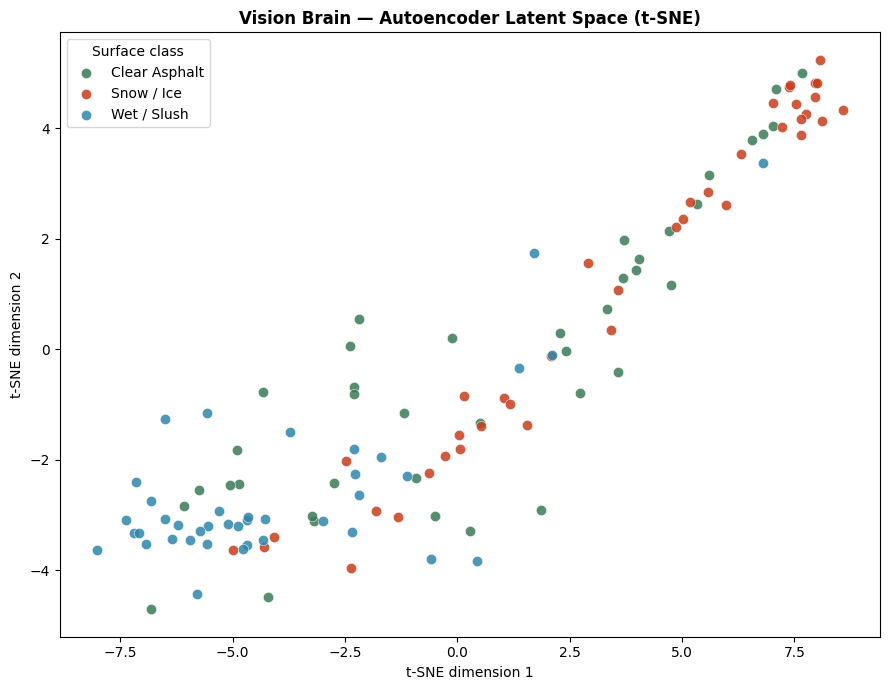


Softmax class probabilities (one example per surface class):
Class            Clear As  Wet / Sl  Snow / I  | Hazard
----------------------------------------------------------------------
Clear Asphalt       0.939     0.012     0.049  | 0.061
Wet / Slush         0.001     0.999     0.000  | 0.999


Snow / Ice          0.000     0.001     0.999  | 1.000

Mean softmax hazard by class:


ResNet18 softmax hazard summary (P_Wet + P_Snow/Ice):
Class             Mean hazard      Std     N
---------------------------------------------
Clear Asphalt           0.251    0.243    15
Wet / Slush             0.860    0.189    15
Snow / Ice              0.989    0.017    15


In [7]:
# ── 6.2c  Latent space extraction, t-SNE, and softmax probabilities ───────────

# Ensure runtime if PART BOOTSTRAP was skipped
if "TORCH_OK" not in globals():
    import sys
    from pathlib import Path as _P
    for _base in [_P.cwd(), *_P.cwd().parents]:
        if (_base / "src" / "vision_brain.py").is_file():
            if str(_base / "src") not in sys.path:
                sys.path.insert(0, str(_base / "src"))
            if "DATA" not in globals():
                _d = _base / "Data"
                globals()["DATA"] = _d if _d.is_dir() else _base / "data"
            if "REPO_ROOT" not in globals():
                globals()["REPO_ROOT"] = _base
            break
    try:
        import torch  # noqa: F401
        TORCH_OK = True
    except Exception:
        TORCH_OK = False

# Safe if 6.2 / 6.2b were skipped (avoids NameError on undefined names)
vision_model = globals().get("vision_model")
ae_model = globals().get("ae_model")
val_ds = globals().get("val_ds")
vision_class_names = globals().get("vision_class_names")
device = globals().get("device", "cpu")

if not TORCH_OK:
    print("PyTorch not available — skip latent / t-SNE analysis.")
elif vision_model is None or ae_model is None or val_ds is None or vision_class_names is None:
    print("Run Sections 6.2 and 6.2b first (ResNet + autoencoder), then re-run this cell.")
else:
    import importlib
    import sys
    if "vision_brain" in sys.modules:
        del sys.modules["vision_brain"]
    import vision_brain
    importlib.reload(vision_brain)

    from vision_brain import (
        labeled_latents_from_val,
        plot_latent_tsne,
        resnet_softmax_probs,
        summarize_softmax_hazard,
        HAZARD_CLASSES,
    )

    print("Extracting autoencoder latent vectors from validation set...")
    latents, latent_labels = labeled_latents_from_val(
        ae_model, val_ds, vision_class_names, device=device, max_per_class=40,
    )
    print(f"  Latent matrix shape: {latents.shape}")

    print("\nRunning t-SNE on latent space...")
    plot_latent_tsne(latents, latent_labels, title="Vision Brain — Autoencoder Latent Space (t-SNE)")

    print("\nSoftmax class probabilities (one example per surface class):")
    print(f"{'Class':<16} " + "  ".join(f"{c[:8]:>8}" for c in vision_class_names) + "  | Hazard")
    print("-" * 70)
    shown = set()
    for i in range(len(val_ds)):
        x_i, y_i = val_ds[i]
        lbl = vision_class_names[int(y_i)]
        if lbl in shown:
            continue
        shown.add(lbl)
        probs = resnet_softmax_probs(vision_model, x_i, vision_class_names, device=device)
        hazard = sum(probs.get(h, 0.0) for h in HAZARD_CLASSES)
        row = "  ".join(f"{probs.get(c, 0.0):8.3f}" for c in vision_class_names)
        print(f"{lbl:<16} {row}  | {hazard:.3f}")

    print("\nMean softmax hazard by class:")
    summarize_softmax_hazard(vision_model, val_ds, vision_class_names, device=device)

**Findings:** Latent space compresses images to 128-dim vectors; t-SNE visualizes class separation; softmax gives interpretable hazard probabilities per surface type.


**Findings & importance:** Produces `vision_resnet18.pt` — the Vision Brain artifact. Even with a small cache, transfer learning from ImageNet enables reasonable wet/snow/ice detection for the multimodal Safety Score fusion.

**What to check in the output:** Training loss should decrease; final weights saved to `models/vision_resnet18.pt`.


In [8]:
# ── PART SYNC → main notebook ──
import subprocess
import sys
from pathlib import Path

def _find_root() -> Path:
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / "scripts" / "sync_notebook_parts.py").is_file():
            return base
    return Path.cwd()

_ROOT = _find_root()
rc = subprocess.run(
    [sys.executable, str(_ROOT / "scripts" / "sync_notebook_parts.py"),
     "--direction", "parts-to-main", "--only", "02_vision_brain.ipynb"],
    cwd=_ROOT,
).returncode
print("Synced to capstone_with_results.ipynb" if rc == 0 else f"Sync failed (exit {rc})")

  02_vision_brain.ipynb → main: 6 code cells (source=outputs only)
Done. Synced 6 cells parts → main.
Synced to capstone_with_results.ipynb
